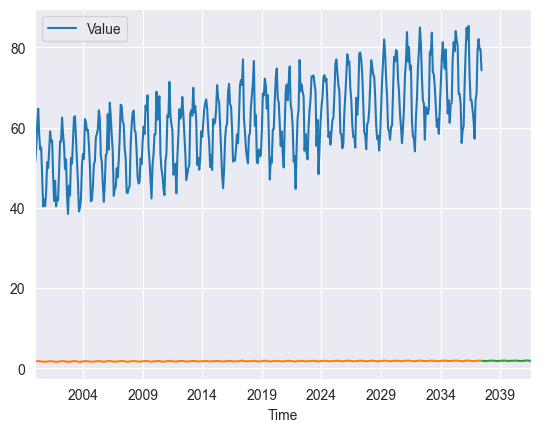

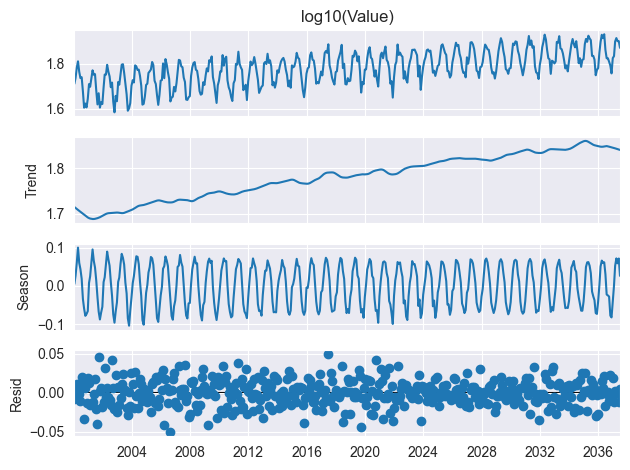

Analizom STL metode nakon rastavljanja vremenske serije na kompomente mozemo uociti da u podcima postoji i trend i sezonalnost.
adf_value=-14.27, 1.368691327400754e-26
na osnovu augmented dickey-fuller testa postoji stacionarnost
Ljung Box test pokazuje da postoji autokorelacija do 30. reda jer je p-vrednost manja od 0.05 za svakog od njih.


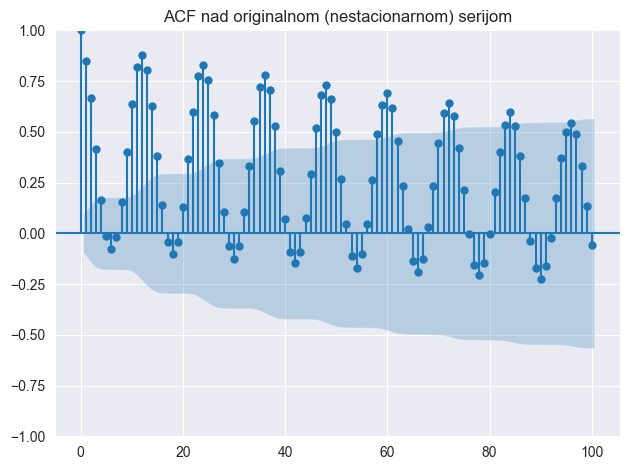

Analizom ACF grafika, zakljucujem da kada je rec o Rolling Window-u korisne vrednosti se krecu od 1-3 a potom od 9-12 i takav format se ponavlja kroz ~7 godina nakon cega nema vise znacaja. Vrednosti za koje se odlucujem ovde su 3 i 12. 12 uzimam takodje zbog toga sto znamo da imamo sezonalnost na 12 meseci.


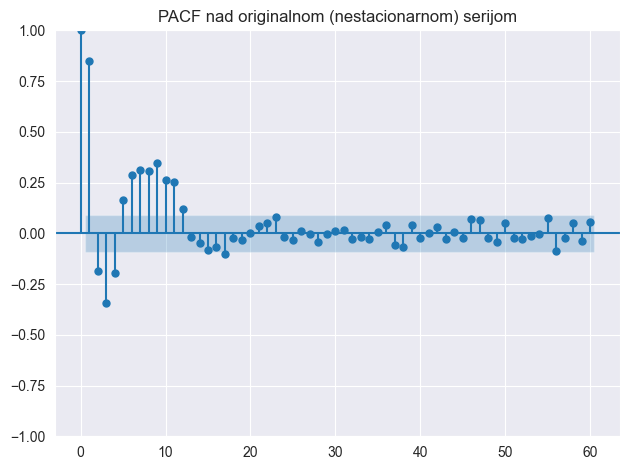

Analizom PACF grafika, zakljucujem da posle 12 meseci, svi ulaze u zonu slucajnog suma, pa mozemo zakljuciti da na prodaju narednog meseca na neki nacin uticu prodaje iz svakog meseca prethodne godine. Odlucujem se da ubacim za 1 mesec lag, ali ovde bi bile i ostale vrednosti do 12, i on, dobri kandidati.


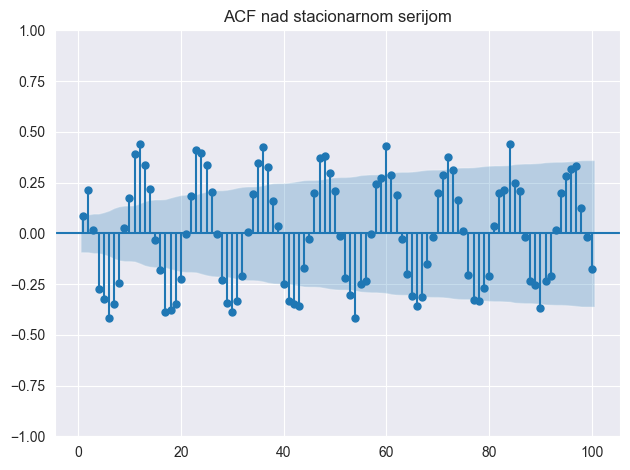

Analizom ACF grafika nad stacionarnim podacima, zakljucujemo da je q=2 pogodna vrednost. Drugi kandidati bi bili q=4,5,6 i jos njih ali sa prekidima. Nakon q=2 nemamo konkretnu vrednost nakon koje mozemo reci da su sve nebitne. Manuelnim testiranjem dobijam da je za q=2 najmanja gerska.


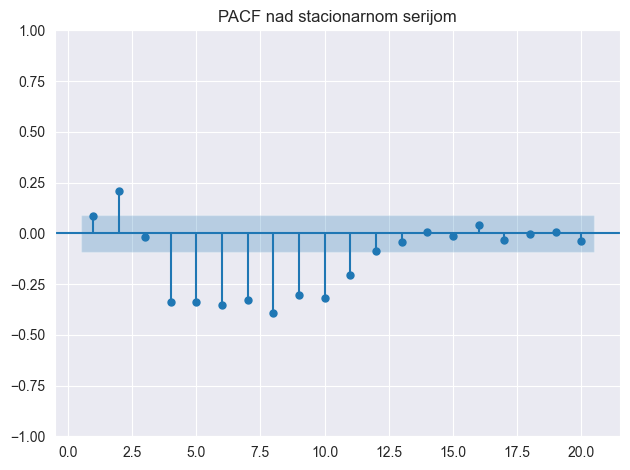

Analizom PACF grafika nad stacionarnim podacima, mozemo zakljuciti da su kandidati p=2,4,5,6,7,8,9,10,11,12 a da je p=12 najbolji kandidat nakon manuelnog testiranja. Posle njega, svi su nebitni.
MAE:  3.297655025649227


In [493]:
from sklearn.metrics import mean_absolute_error
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

# proverio sam podatke i nema nedostajucih
df_test = pd.read_csv("./data/test.csv", sep=',')
df_train = pd.read_csv("./data/train.csv", sep=',')

# postavljam mesec kao indeks da bih dobio vremensku seriju
df_train['Time'] = pd.to_datetime(df_train['Time'])
df_train = df_train.set_index('Time')
df_train = df_train.asfreq('ME')

df_test['Time'] = pd.to_datetime(df_test['Time'])
df_test = df_test.set_index('Time')
df_test = df_test.asfreq('ME')

df_train.plot()

"""
Analizom amplituda za svaku godinu, i crtanjem na grafik, zakljucujem da nemamo povecanje amplitude kroz vreme.
"""

# 1. ANALIZA VREMENSKE SERIJE NAD TRENING SKUPOM
# 1.1 GRAFICKI PRIKAZ SERIJE I NJENIH KOMPONENTI
# Radim logaritam na trening

df_train['log10(Value)'] = np.log10(df_train['Value'])
df_train['log10(Value)'].plot()

# Radi logaritam na test

df_test['log10(Value)'] = np.log10(df_test['Value'])
df_test['log10(Value)'].plot()

# Koristimo STL metod

stl = STL(df_train['log10(Value)']).fit()
trend, seasonal, resid = stl.trend, stl.seasonal, stl.resid # izvlacimo i komponente odvojeno
stl.plot()
plt.show()
print("Analizom STL metode nakon rastavljanja vremenske serije na kompomente mozemo uociti da u podcima postoji i trend i sezonalnost.")

# 1.2 PROVERA I OBEZBEDJIVANJE STACIONARNOSTI

"""
# Proveravamo inicijalno stanje serije - da li postoji stacionarnost ?
adf_value = adfuller(df_train['Value'])[0]
p_value = adfuller(df_train['Value'])[1]
print(f'{adf_value=:.2f}, {p_value=:.2f}')
if p_value <= 0.05: print('postoji stacionarnost')
else: print('ne postoji stacionarnost')

# Proveravamo stacionarnost sa logaritmovanim podacima
adf_value = adfuller(df_train['log10(Value)'])[0]
p_value = adfuller(df_train['log10(Value)'])[1]
print(f'{adf_value=:.2f}, {p_value=:.2f}')
if p_value <= 0.05: print('postoji stacionarnost')
else: print('ne postoji stacionarnost')
# i dalje nije dovoljno dobro, ali ide na bolje
"""

# Pokusacu da resim problem stacionarnosti diferenciranjem
df_train['stationary_data'] = df_train['log10(Value)'].diff()
df_train = df_train.dropna(subset=['stationary_data'])

adf_value = adfuller(df_train['stationary_data'])[0]
p_value = adfuller(df_train['stationary_data'])[1]
print(f'{adf_value=:.2f}, {p_value}')
if p_value <= 0.05: print('na osnovu augmented dickey-fuller testa postoji stacionarnost')
else: print('na osnovu augmented dickey-fuller testa ne postoji stacionarnost')
# plt.plot(df_train['stationary_data'])

result = acorr_ljungbox(df_train['Value'], lags=30, return_df=True)
#result
print("Ljung Box test pokazuje da postoji autokorelacija do 30. reda jer je p-vrednost manja od 0.05 za svakog od njih.")

#  2. ISPITUJEM KARAKTERISTIKE POMOCU ACF I PACF

# Ovde radim ACF i PACF nad NE STACIONARNIM odnosno ORIGINAL podacima

plot_acf(df_train["Value"], lags=100)
plt.title("ACF nad originalnom (nestacionarnom) serijom")
plt.tight_layout()
plt.show()

print("Analizom ACF grafika, zakljucujem da kada je rec o Rolling Window-u korisne vrednosti se krecu od 1-3 a potom od 9-12 i takav format se ponavlja kroz ~7 godina nakon cega nema vise znacaja. Vrednosti za koje se odlucujem ovde su 3 i 12. 12 uzimam takodje zbog toga sto znamo da imamo sezonalnost na 12 meseci.")
# ovo nam u sustini govori da ukoliko uzmemo sumu prethodna 3 meseca, mozemo potencijalno pomoci nasem modelu da dobije bolji rezultat predikcije

plot_pacf(df_train["Value"], lags=60)
plt.title("PACF nad originalnom (nestacionarnom) serijom")
plt.tight_layout()
plt.show()

print("Analizom PACF grafika, zakljucujem da posle 12 meseci, svi ulaze u zonu slucajnog suma, pa mozemo zakljuciti da na prodaju narednog meseca na neki nacin uticu prodaje iz svakog meseca prethodne godine. Odlucujem se da ubacim za 1 mesec lag, ali ovde bi bile i ostale vrednosti do 12, i on, dobri kandidati.")

df_train['roll_3'] = df_train['log10(Value)'].diff().rolling(3).mean()
df_train['roll_12'] = df_train['log10(Value)'].diff().rolling(12).mean()

df_train['lag_1'] = df_train['log10(Value)'].diff().shift(1)

# 2.1 Vrsimo odabir parametara modela na osnovu ACF i PACF

plot_acf(df_train['stationary_data'], lags=100, zero=False)
plt.title("ACF nad stacionarnom serijom")
plt.tight_layout()
plt.show()

print("Analizom ACF grafika nad stacionarnim podacima, zakljucujemo da je q=2 pogodna vrednost. Drugi kandidati bi bili q=4,5,6 i jos njih ali sa prekidima. Nakon q=2 nemamo konkretnu vrednost nakon koje mozemo reci da su sve nebitne. Manuelnim testiranjem dobijam da je za q=2 najmanja gerska.")

plot_pacf(df_train['stationary_data'], lags=20, zero=False, method="ywm")
plt.title("PACF nad stacionarnom serijom")
plt.tight_layout()
plt.show()

print("Analizom PACF grafika nad stacionarnim podacima, mozemo zakljuciti da su kandidati p=2,4,5,6,7,8,9,10,11,12 a da je p=12 najbolji kandidat nakon manuelnog testiranja. Posle njega, svi su nebitni.")

p, d, q = 12, 1, 2
arima_model = ARIMA(df_train['log10(Value)'], order=(p, d, q)).fit()
#print(arima_model.summary())

y_test_pred_log = arima_model.predict(start=df_test.index[0], end=df_test.index[-1])

# inverzujemo logaritam
y_test_pred = np.power(10, y_test_pred_log)

mae_test = mean_absolute_error(df_test['Value'], y_test_pred)

"""
plt.figure(figsize=(12,4))
plt.plot(df_train['Value'], label='train', alpha=0.3)
plt.plot(df_test['Value'], label='test', alpha=0.5)
plt.plot(y_test_pred, label='pred (test)', linewidth=2)
plt.legend()
plt.title("Predikcija na test skupu (originalna skala)")
plt.show()
"""

print("MAE: ", mae_test)